In [5]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)
#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray93"),
    legend.box = "vertical",
    legend.direction = "vertical",
    legend.key.height = unit(0.1,"snpc"),
    legend.key.width  = unit(0.1,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 24),
    axis.text.x  = element_text(size = 20),
    axis.text.y = element_text(size = 20),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 20)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")


Attaching package: ‘IRdisplay’


The following object is masked from ‘package:xtable’:

    display




# Clase 3 - B: Plots, escalas, ajustes
### (con escenas de la vida real)


<img src="https://media1.tenor.com/images/2697a170d27ca031db9b7e96ec1b9e41/tenor.gif?itemid=11865968" width="800"/>

# Ecuaciones y Linealización


El único modelo de ajuste que vamos a ver todes es el famoso ***ajuste lineal de una recta*** (no es una redundancia, ojo con la gente preclara). Ajuste lineal se refiere a ***lineal en parámetros***. Ajuste de una recta se refiere al modelo que vamos a ajustar, una recta: 

$$y_{a,b}\;(x) = a x + b$$

Puede que alguno se aventure un poco más, pero el ajuste lineal es el único que vamos a ver formalmente. Lo vamos a ver en detalle, con varias revisitas a lo largo del curso. También hay razones históricas:

* Se puede hacer a mano con ciertos supuestos.
* Simplifica el análisis de resultados.
* Es robusto.
* Es tan ciego que permite ajustar cualquier cosa (ojo que nos damos cuenta si están mintiendo con sus ajustes).

<div class="alert alert-block alert-danger">
    Los <b>ajustes lineales</b> son los únicos que pueden resolverse a mano de manera razonablemente sencilla (al aumentar la cantidad de parámetros que deseamos determinar a partir de unos datos, tenemos que resolver más ecuaciones). La interpretación de los resultados también es <b><i>sencilla</i></b> (ojo, para personas iniciadas en la fe). Esto hace que <b><i>linealizar</i></b> ecuaciones para ajustar parámetros sea nuestro pan de cada día.
     
</div>


    

### Ecuaciones y Linealización: crecimiento exponencial

La idea es que tenemos una variable $y$ que ***suponemos*** crece exponencialmente cuando crece la variable $x$. Esto es, suponemos una relación:

$$y \, (x) = A e^{ax}$$

El cambio de variables usual es:
$$ln(y(x)) = ln(A e^{ax}) = ln(A) + ln(e^{ax}) =ln(A) + ax$$

Fíjense que el último término es una recta de ordenada al origen $ln(A)$ y pendiente $a$. $a \in \mathcal{R} \neq 0$

Ahorita lo hacemos en código, primero con la fórmula

In [6]:
#definimos parámetros
A <- 10; a <- 1;

#definimos x e y
x <- seq(0,0.5,0.001)
y <- A*exp(a*x)

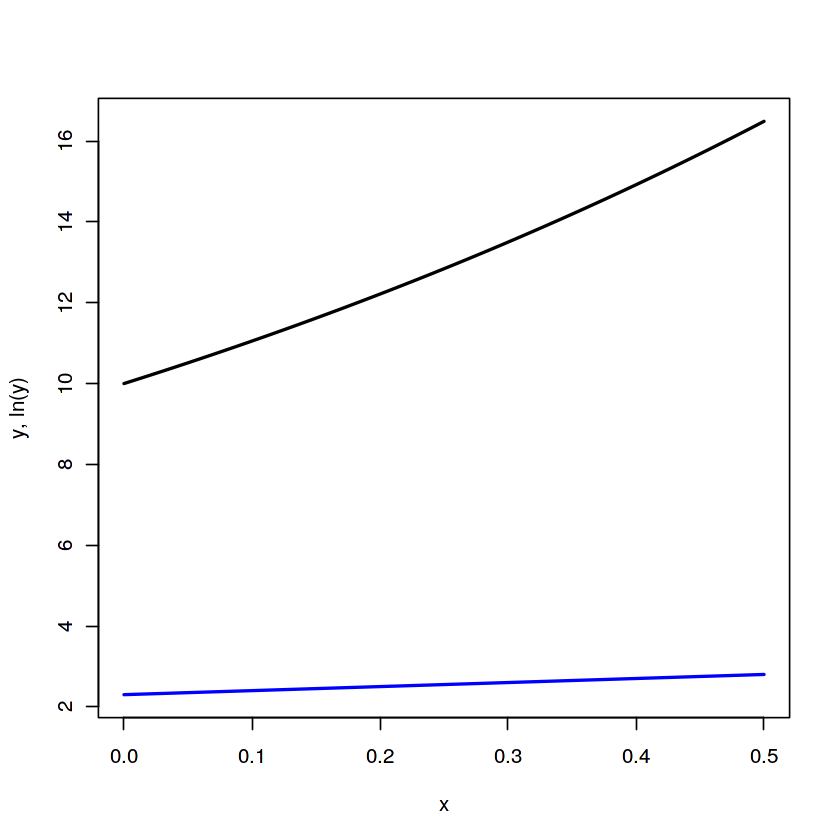

In [7]:
#ploteamos
plot(x,y, type = "l", lwd =2, #type = "l" grafica líneas, lwd = 2, ancho de línea
     ylim = c(min(range(y),range(log(y)) ), max(range(y),range(log(y)) )), #límites piolas
     ylab = "y, ln(y)")
#cambiamos variables
lines(x,log(y), lwd = 2, col = "blue")

 Vemos que:
* La línea negra es la exponencial.
* La línea azul es el logaritmo de la exponencial y es una recta.

Tarea:

Defina una exponencial negativa (cambiando el código de arriba). Haga las gráficas.

### Ejemplo exponencial más sucia

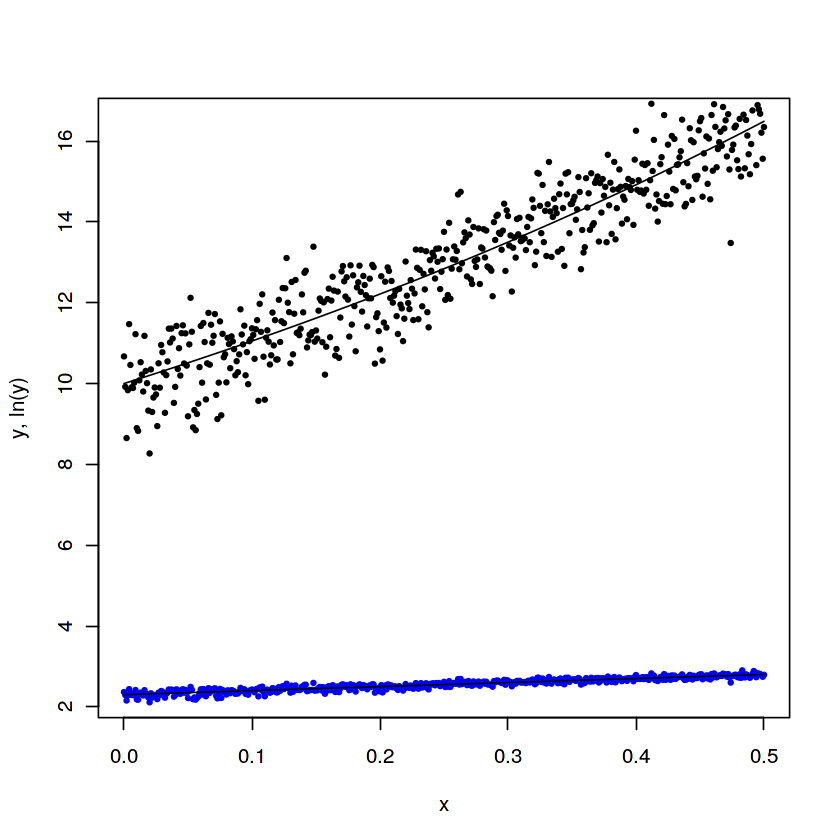

In [8]:
yruido <- y + rnorm(mean = 0, sd = 0.75, n = length(y))
#ploteamos
plot(x,yruido, ylim = c(min(range(y),range(log(y)) ), max(range(y),range(log(y)) )), #límites piolas
     ylab = "y, ln(y)", pch = 16, cex = 0.6) # pch es el símbolo que usa para graficar puntos. cex = tamaño punto
#cambiamos variables
points(x,log(yruido), pch = 16, cex = 0.6,col = "blue")
lines(x,y)
lines(x, log(y))

Vemos que:
* El ruido es grande en escala lineal y pequeño en escala logarítmica
* No se ven muchos detalles si no vemos la escala transformada sola (el rango de la escala lineal es demasiado grande)

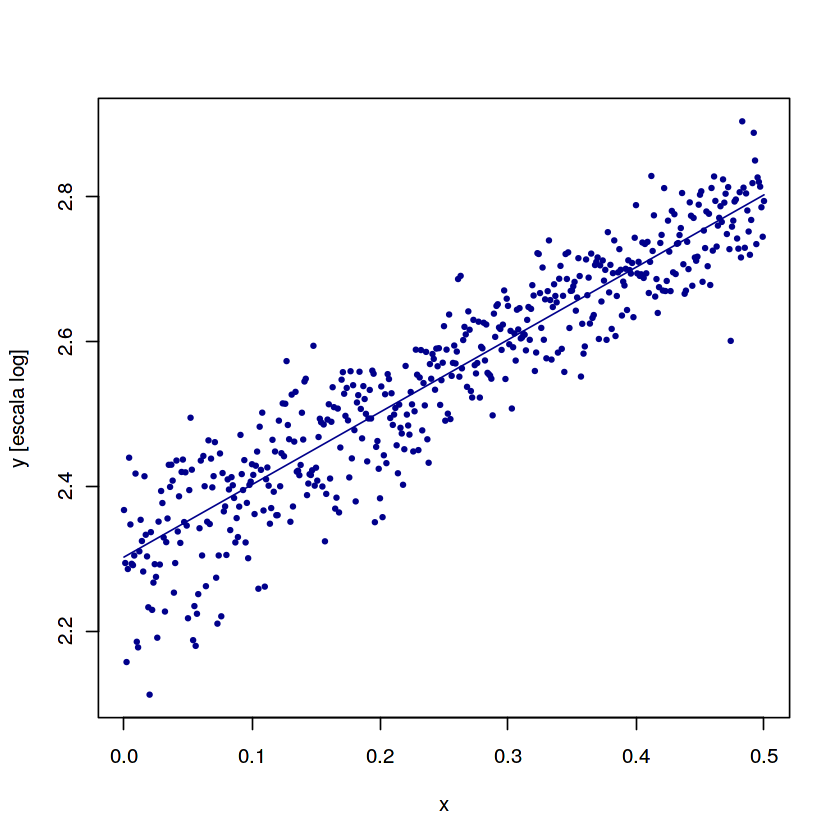

In [9]:
#ploteamos
plot(x,log(yruido), ylim = c(min(range(log(yruido)) ), max(range(log(yruido)) )), #límites piolas
     ylab = "y [escala log]", pch = 16, cex = 0.6, col = "blue4") # pch es el símbolo que usa para graficar puntos. cex = tamaño punto
#cambiamos variables
lines(x, log(y), col = "blue4")

Vemos que:
* Los puntos, a pesar del ruido, siguen pareciendo una recta.
* Se ve lindo.

### Crecimiento exponencial en datos de verdad

* Cargamos un dataset de la pandemia en Argentina.
* Tiene muchos datos

In [10]:
#instala librería "readr"
#install.packages("readr", dependencies = T); #esto permite cargar datos directamente desde la red

In [1]:
library("readr")
suppressWarnings(
p <- read_csv('https://docs.google.com/spreadsheets/d/16-bnsDdmmgtSxdWbVMboIHo5FRuz76DBxsz_BbsEVWA/export?format=csv&id=16-bnsDdmmgtSxdWbVMboIHo5FRuz76DBxsz_BbsEVWA&gid=0')
)

Rows: 13342 Columns: 19

── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): fecha, osm_admin_level_2, osm_admin_level_4, osm_admin_level_8, to...
dbl  (8): dia_inicio, dia_cuarentena_dnu260, tot_casosconf, nue_casosconf_di...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



**Si no funciona lo anterior, los datos hasta el día 15/10/20 están en covid19.csv**

In [2]:
p[60:90 , ]

fecha,dia_inicio,dia_cuarentena_dnu260,osm_admin_level_2,osm_admin_level_4,osm_admin_level_8,tot_casosconf,nue_casosconf_diff,tot_fallecidos,nue_fallecidos_diff,tot_recuperados,tot_terapia,test_RT-PCR_negativos,test_RT-PCR_total,transmision_tipo,informe_tipo,informe_link,observacion,covid19argentina_admin_level_4
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
20/03/2020,16,NA,Argentina,Neuquén,NA,159,1,7,0,NA,NA,NA,NA,importado,informe nacional,https://www.argentina.gob.ar/sites/default/files/20-03-20_reporte_diario_covid_19_2.pdf,NA,neuquen
20/03/2020,16,NA,Argentina,Santiago del Estero,NA,160,1,7,0,NA,NA,NA,NA,importado,informe nacional,https://www.argentina.gob.ar/sites/default/files/20-03-20_reporte_diario_covid_19_2.pdf,NA,santiago-del-estero
20/03/2020,16,NA,Argentina,Indeterminado,NA,160,0,7,0,27,NA,872,1030,importado,informe nacional,https://www.argentina.gob.ar/sites/default/files/20-03-20_reporte_diario_covid_19_2.pdf,NA,no-data
21/03/2020,17,1,Argentina,CABA,NA,189,29,7,0,NA,NA,NA,NA,transmision local,informe nacional,https://www.argentina.gob.ar/sites/default/files/21-03-20-reporte-diario_covid19.pdf,NA,capital-federal
21/03/2020,17,1,Argentina,Buenos Aires,NA,203,14,8,1,NA,NA,NA,NA,transmision local,informe nacional,https://www.argentina.gob.ar/sites/default/files/21-03-20-reporte-diario_covid19.pdf,NA,buenos-aires
21/03/2020,17,1,Argentina,Chaco,NA,208,5,8,0,NA,NA,NA,NA,transmision local,informe nacional,https://www.argentina.gob.ar/sites/default/files/21-03-20-reporte-diario_covid19.pdf,NA,chaco
21/03/2020,17,1,Argentina,Mendoza,NA,213,5,8,0,NA,NA,NA,NA,transmision local,informe nacional,https://www.argentina.gob.ar/sites/default/files/21-03-20-reporte-diario_covid19.pdf,NA,mendoza
21/03/2020,17,1,Argentina,Córdoba,NA,217,4,8,0,NA,NA,NA,NA,transmision local,informe nacional,https://www.argentina.gob.ar/sites/default/files/21-03-20-reporte-diario_covid19.pdf,NA,cordoba
21/03/2020,17,1,Argentina,Tierra del Fuego,NA,220,3,8,0,NA,NA,NA,NA,transmision local,informe nacional,https://www.argentina.gob.ar/sites/default/files/21-03-20-reporte-diario_covid19.pdf,NA,tierra-del-fuego


De todos estos datos nos vamos a quedar con tres columnas:
* Fecha (sólo para tener referencias, porque son difíciles de manejar en lenguaje)
* Día inicio de pandemia
* tot_fallecidos

In [13]:
po <- data.frame(fecha = p$fecha, dia = p$dia_inicio, fallecides = p$tot_fallecidos); head(po,20)

,fecha,dia,fallecides
,<fct>,<dbl>,<dbl>
1,2/03/2020,1,0
2,3/03/2020,2,0
3,4/03/2020,3,0
4,5/03/2020,4,2
5,6/03/2020,5,2
6,7/03/2020,6,2
7,8/03/2020,7,2
8,9/03/2020,8,3
9,9/03/2020,8,3


De lo anterior vemos que:
* El número de personas fallecidas se repite varias veces (porque la tabla original está desagregada).
* Nos deberíamos deshacer de las repeticiones, pero queda de tarea.

Podríamos planetear la siguiente pregunta:

***¿El ASPO del principio (el primer mes de encierro), impidió muertes?***

* El ASPO comenzó el día 17 de la pandemia (21 de marzo)
* Si bien sigue, vamos a proponer que duró un mes, hasta el 21 de abril.
* Los efectos del inicio y el fin tienen una demora de dos semanas, por lo que tardan los síntomas en manifestarse...

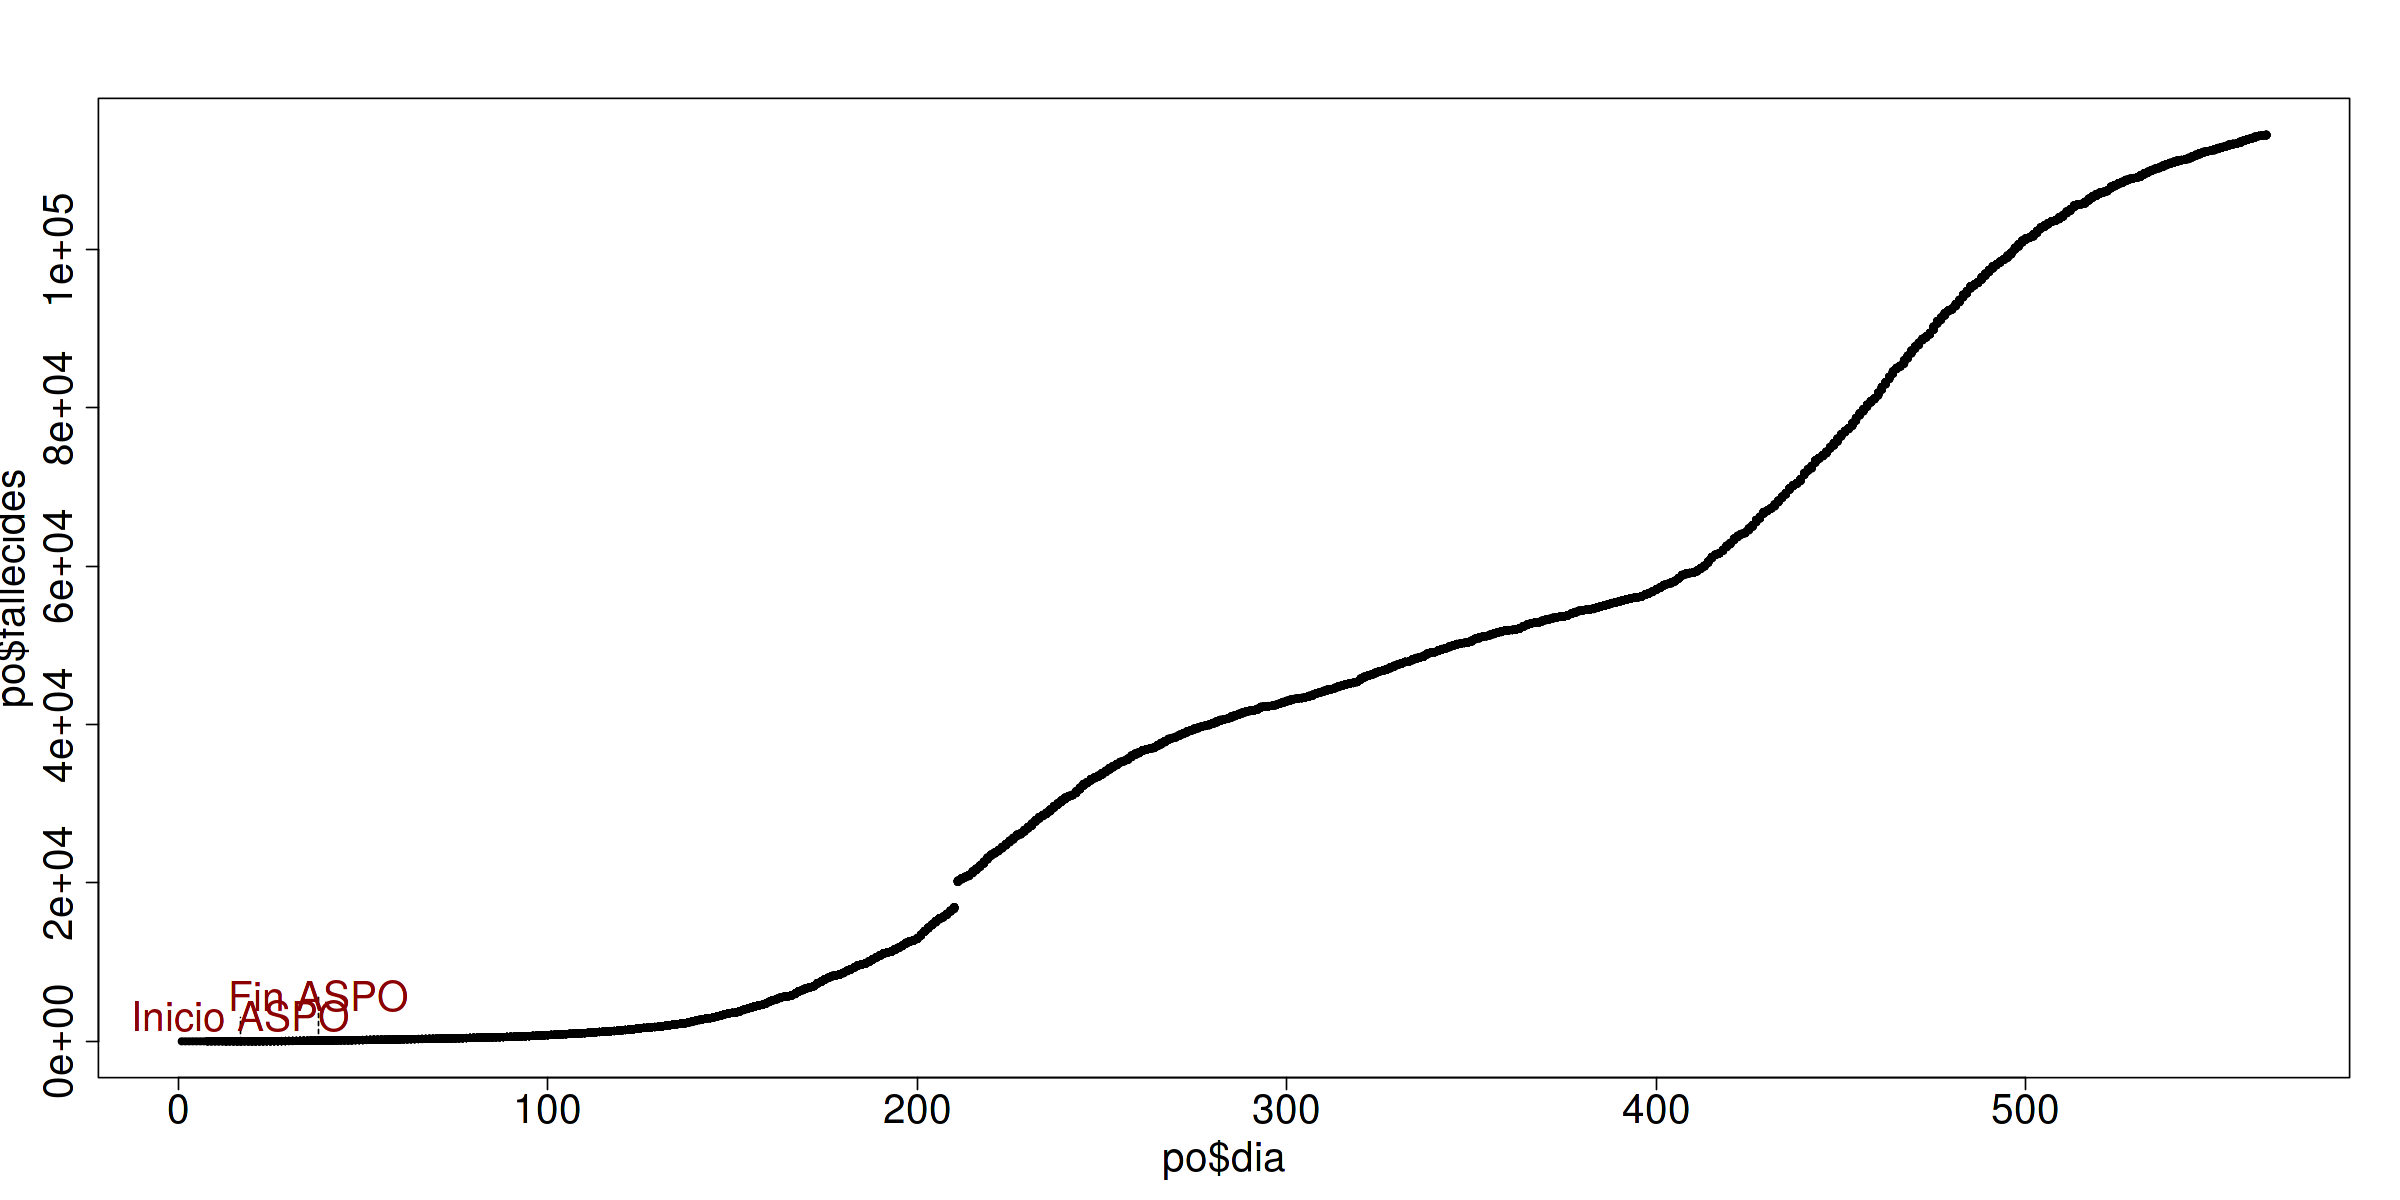

In [14]:
fig(20,10)
plot(po$dia,po$fallecides, cex.axis = 2, cex.lab  = 2, pch = 16, cex = 0.8)
segments(x0 = c(17,38), x1 = c(17,38),y0 = c(0,0),y1 = c(3000,5500), lty = 2)
#texto de etiquetas dentro del gráfico (no lo use casi nunca)
text(x = c(17,38), y = c(3200,5700), labels = c("Inicio ASPO", "Fin ASPO"),   cex  = 2, col = "Red4")

No se ve mucho, ergo, no podemos decir si el ASPO tiene efecto o no.

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“3 y values <= 0 omitted from logarithmic plot”
Warning message in max(po$muertos):
“ningun argumento finito para max; retornando -Inf”


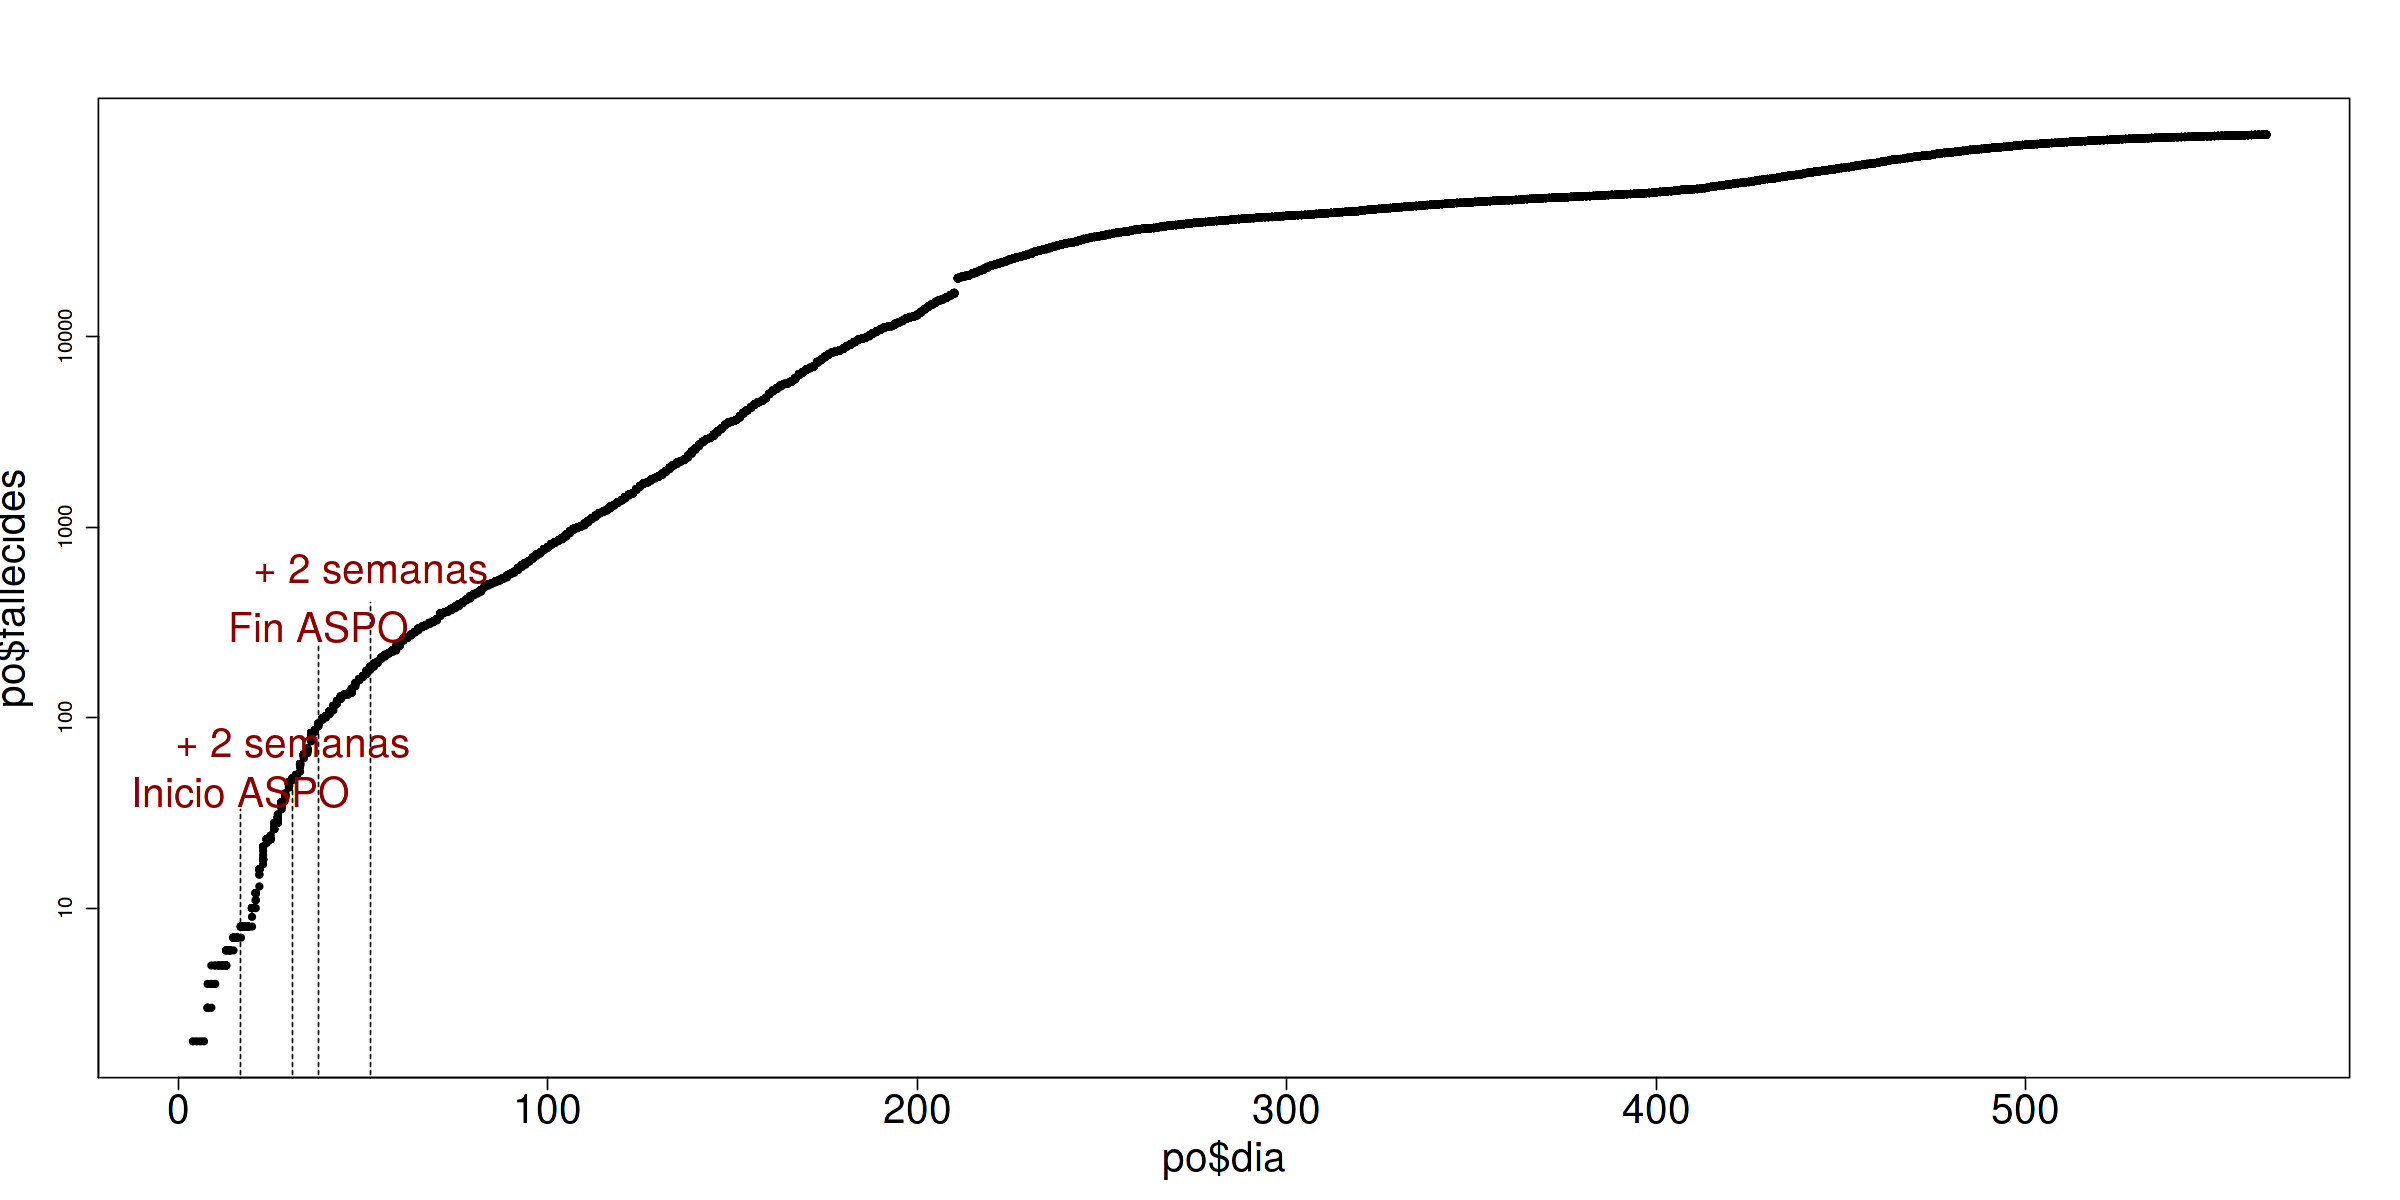

In [15]:
plot(po$dia,po$fallecides,log = "y", cex.axis = 2, cex.lab  = 2, pch = 16, cex = 0.8, yaxt = "n")
labels <- c(10^(seq(0,4,1)), max(po$muertos))
axis(2,at=labels,labels=labels)
segments(x0 = c(17,17 + 14,38, 38 + 14), x1 = c(17,17 + 14,38, 38 + 14),y0 = c(1,1,1,1),y1 = exp(c(3.5,3.8, 5.5, 6)), lty = 2)
#texto de etiquetas dentro del gráfico (no lo use casi nunca)
text(x = c(17,17+14,38, 38 + 14), y = exp(c(3.7,4.3,5.7,6.4)), labels = c("Inicio ASPO", "+ 2 semanas","Fin ASPO", "+ 2 semanas"),   cex  = 2, col = "Red4")


* El periodo de incubación + enfermedad puede ser de dos semanas, eso explica la *demora* en el efecto.
* La escala log nos permite ver estas cosas, en la escala lineal no se ve nada.

# Tarea

Leer Clase 3 - A.

Estime, utilizando todos los conocimientos disponibles, la cantidad de personas fallecidas totales al final de este curso, 20/12/20.